In [133]:
import matplotlib.pyplot as plt
import numpy as np
from sympy import symbols, diff, integrate, Eq, solve, exp, cos, sin, sqrt, log, pi, ceiling

## Задача 1
Да се намери полином от трета степен на най-добро средноквадратично приближение в интервала $[0.1, 0.2]$ при тегло $\mu(x) = 1$ за функцията $f(x) = \ln^2 x$. Да се илюстрира графично.

---

In [134]:
def f(x):
    return log(x)*log(x)+1

a,b,c,d,x = symbols('a,b,c,d,x')

def pol(x, a, b, c,d):
    return a*x**3 + b*x**2 + c*x + d

def phi(a, b, c, d):
    return integrate((f(x)- pol(x, a, b, c, d))**2, (x, 0.1 , 0.2))

equations = [Eq(diff(phi(a,b,c,d), a), 0), Eq(diff(phi(a,b,c,d), b), 0), Eq(diff(phi(a,b,c,d), c), 0), Eq(diff(phi(a,b,c,d), d), 0)]
sol = solve(equations)
print(solve(equations))

{a: -734.543537175009, b: 467.791908150769, c: -116.015812470530, d: 13.9530297526983}


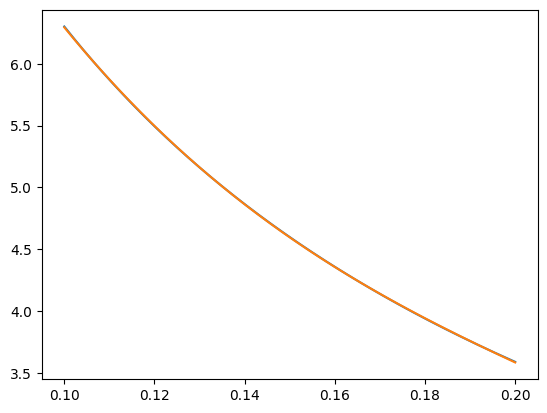

In [135]:
def pol_actual(x):
    return float(sol[a])*x**3 + float(sol[b])*x**2 + float(sol[c])*x + float(sol[d])

x_axis = np.linspace(0.1, 0.2, 1000)
plt.plot(x_axis, np.log(x_axis)*np.log(x_axis)+1)
plt.plot(x_axis, pol_actual(x_axis))

## Задача 2
Да се намери n, така че n-тата съставна квадратурна формула на Симпсън да приближава

I = ∫ (от π/4 до π/2) cos(x) sin(2x) dx

с грешка, не по-голяма от ε = 10⁻⁵. Да се пресметне това приближение.

---

In [136]:
eps = 10**(-5)
x = symbols('x')
right = diff(cos(x) * sin(2*x),x, 4)
equation = Eq(right, 0)
equation

Eq(40*sin(x)*cos(2*x) + 41*sin(2*x)*cos(x), 0)

In [137]:
M4 = 32
b= pi/2
a = pi/4

n_real = ((b - a)**5 * M4 / (2880 * eps))**(1/4)

ceiling(float(n_real))

5

## Задача 3
По метода на неопределените коефициенти да се изведе квадратурна формула на Гаус с 3 възела и тегло μ(x) = 1 в интервала [-π, 0]. Последната да се използва за приближено пресмятане на

∫ (от -π до 0) (cos³(x) + 141) dx.

---

In [138]:
# Gauss-Legendre 3 nodes
x, A1, x1, A2, x2, A3, x3 = symbols('x, A1, x1, A2, x2, A3, x3')
eq1 = Eq(A1 + A2 + A3, integrate(1,(x, -1, 1)))
eq2 = Eq(A1*x1 + A2*x2 + A3*x3, integrate(x,(x, -1, 1)))
eq3 = Eq(A1*x1**2 + A2*x2**2 + A3*x3**2, integrate(x**2,(x, -1, 1)))
eq4 = Eq(A1*x1**3 + A2*x2**3 + A3*x3**3, integrate(x**3,(x, -1, 1)))
eq5 = Eq(A1*x1**4 + A2*x2**4 + A3*x3**4, integrate(x**4,(x, -1, 1)))
eq6 = Eq(A1*x1**5 + A2*x2**5 + A3*x3**5, integrate(x**5,(x, -1, 1)))
solutions = solve([eq1, eq2, eq3, eq4, eq5, eq6])
solutions

[{A1: 5/9, A2: 5/9, A3: 8/9, x1: -sqrt(15)/5, x2: sqrt(15)/5, x3: 0},
 {A1: 5/9, A2: 5/9, A3: 8/9, x1: sqrt(15)/5, x2: -sqrt(15)/5, x3: 0},
 {A1: 5/9, A2: 8/9, A3: 5/9, x1: -sqrt(15)/5, x2: 0, x3: sqrt(15)/5},
 {A1: 5/9, A2: 8/9, A3: 5/9, x1: sqrt(15)/5, x2: 0, x3: -sqrt(15)/5},
 {A1: 8/9, A2: 5/9, A3: 5/9, x1: 0, x2: -sqrt(15)/5, x3: sqrt(15)/5},
 {A1: 8/9, A2: 5/9, A3: 5/9, x1: 0, x2: sqrt(15)/5, x3: -sqrt(15)/5}]

In [139]:
b = 0
a = -np.pi

def f(t):
    x = (b - a)/2 * t + (a + b)/2
    return cos(x)**3 + 141

integral_approx = (b-a)/2 * (5/9*f(-np.sqrt(3/5)) + 8/9*f(0) + 5/9*f(np.sqrt(3/5)))
x = symbols('x')
print(integral_approx)
print(float(integrate(cos(x)**3 + 141, (x,a,b))))

442.964564156161
442.9645641561608


**1. Защо на практика се налага употребата на численни методи?**  
Защото много задачи нямат точно аналитично решение или то е много сложно. Числените методи дават приближени решения с желана точност.

---

**2. Какво разбирате под алгебрическа степен на точност на една квадратурна формула?**  
Това е най-високата степен на полином, за който формулата дава точен интеграл.

---

**3. Как можем да дефинираме разстояние, ако имаме зададена норма?**  
Разстоянието между две точки се дефинира като нормата на разликата им:  
\( d(x, y) = \| x - y \| \).

---

**4. Защо формулите на правоъгълниците, трапециите и Симпсън се наричат интерполационни?**  
Защото те заместват функцията с интерполационен полином (константа, права, парабола) и интегрират точно този полином.

---

**5. Интерполационен метод ли е методът на най-малките квадрати? Обосновете се.**  
Не. Той е апроксимационен метод – функцията не минава точно през точките, а минимизира сумата от квадратите на грешките.